# Tarea Ecuaciones Métodos Iterativos
## Analisis numérico
**Profersor: Miriam Sosa Díaz**

**Ayudante: Andrea Fernanda Rodriguez**

**Nombre: Gabriel Fernando Rosas Zepeda**

# Método de Bisección
## Ejercicio 1: Raíz positiva de $f(x) = e^x - 3x$

**Objetivo:** Encontrar la raíz positiva de $f(x) = e^x - 3x$ en el intervalo $[1, 2]$, con tolerancia $\varepsilon = 10^{-4}$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Configuración general de matplotlib
plt.rcParams.update({'font.size': 12, 'figure.dpi': 110})

## 1. Definición de la función y verificación del intervalo

In [2]:
def f(x):
    return np.exp(x) - 3 * x

a0, b0 = 1.0, 2.0
tol = 1e-4

fa, fb = f(a0), f(b0)
print("=" * 55)
print("  Verificación del Teorema de Bolzano")
print("=" * 55)
print(f"  f({a0}) = e^{a0} - 3·{a0} = {fa:.6f}")
print(f"  f({b0}) = e^{b0} - 3·{b0} = {fb:.6f}")
print(f"  f(a)·f(b) = {fa*fb:.6f}", "< 0 ✓" if fa * fb < 0 else "> 0 ✗")
print("=" * 55)

# Número mínimo de iteraciones estimado
n_min = int(np.ceil(np.log2((b0 - a0) / tol)))
print(f"\n  Iteraciones estimadas: n > log₂(1/{tol}) ≈ {np.log2(1/tol):.4f}")
print(f"  → Se requieren al menos n = {n_min} iteraciones")

  Verificación del Teorema de Bolzano
  f(1.0) = e^1.0 - 3·1.0 = -0.281718
  f(2.0) = e^2.0 - 3·2.0 = 1.389056
  f(a)·f(b) = -0.391322 < 0 ✓

  Iteraciones estimadas: n > log₂(1/0.0001) ≈ 13.2877
  → Se requieren al menos n = 14 iteraciones


## 2. Algoritmo de Bisección

In [3]:
def biseccion(f, a, b, tol=1e-4, max_iter=100):
    """
    Método de bisección para encontrar raíces de f en [a, b].

    Parámetros
    ----------
    f        : función continua
    a, b     : extremos del intervalo con f(a)·f(b) < 0
    tol      : tolerancia (criterio de parada: (b-a)/2 < tol)
    max_iter : número máximo de iteraciones

    Retorna
    -------
    tabla  : lista de dicts con la información de cada iteración
    raiz   : aproximación final de la raíz
    """
    if f(a) * f(b) >= 0:
        raise ValueError("f(a) y f(b) deben tener signos opuestos.")

    tabla = []
    for n in range(1, max_iter + 1):
        c = (a + b) / 2.0
        fc = f(c)
        error = (b - a) / 2.0

        tabla.append({
            'n'    : n,
            'a_n'  : a,
            'b_n'  : b,
            'c_n'  : c,
            'f(c_n)': fc,
            'error': error
        })

        if error < tol or fc == 0:
            break

        if f(a) * fc < 0:
            b = c
        else:
            a = c

    return tabla, c


tabla, raiz = biseccion(f, a0, b0, tol=tol)
print(f"Algoritmo ejecutado correctamente — {len(tabla)} iteraciones.")

Algoritmo ejecutado correctamente — 14 iteraciones.


## 3. Tabla de iteraciones completa

In [4]:
df = pd.DataFrame(tabla)

# Columna de signo para facilitar la lectura
df['signo f(c_n)'] = df['f(c_n)'].apply(lambda v: '< 0' if v < 0 else '> 0')

# Formato de visualización
display_df = df[['n', 'a_n', 'b_n', 'c_n', 'f(c_n)', 'signo f(c_n)', 'error']].copy()
display_df.columns = ['n', 'aₙ', 'bₙ', 'cₙ', 'f(cₙ)', 'signo', 'error = (b−a)/2']

pd.set_option('display.float_format', '{:.7f}'.format)
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 100)

print("=" * 80)
print("         TABLA DE ITERACIONES — Método de Bisección")
print(f"         f(x) = eˣ − 3x,  [a,b] = [1, 2],  ε = {tol}")
print("=" * 80)
print(display_df.to_string(index=False))
print("=" * 80)
print(f"\n  Raíz aproximada : x* ≈ {raiz:.7f}")
print(f"  Raíz exacta     : x* ≈ 1.5121345...")
print(f"  Total iteraciones: {len(tabla)}")

         TABLA DE ITERACIONES — Método de Bisección
         f(x) = eˣ − 3x,  [a,b] = [1, 2],  ε = 0.0001
 n        aₙ        bₙ        cₙ      f(cₙ) signo  error = (b−a)/2
 1 1.0000000 2.0000000 1.5000000 -0.0183109   < 0        0.5000000
 2 1.5000000 2.0000000 1.7500000  0.5046027   > 0        0.2500000
 3 1.5000000 1.7500000 1.6250000  0.2034190   > 0        0.1250000
 4 1.5000000 1.6250000 1.5625000  0.0832332   > 0        0.0625000
 5 1.5000000 1.5625000 1.5312500  0.0302032   > 0        0.0312500
 6 1.5000000 1.5312500 1.5156250  0.0053904   > 0        0.0156250
 7 1.5000000 1.5156250 1.5078125 -0.0065981   < 0        0.0078125
 8 1.5078125 1.5156250 1.5117188 -0.0006384   < 0        0.0039062
 9 1.5117188 1.5156250 1.5136719  0.0023673   > 0        0.0019531
10 1.5117188 1.5136719 1.5126953  0.0008623   > 0        0.0009766
11 1.5117188 1.5126953 1.5122070  0.0001114   > 0        0.0004883
12 1.5117188 1.5122070 1.5119629 -0.0002637   < 0        0.0002441
13 1.5119629 1.5122070 

## 4. Visualización
### 4.1 Gráfica de la función y la raíz

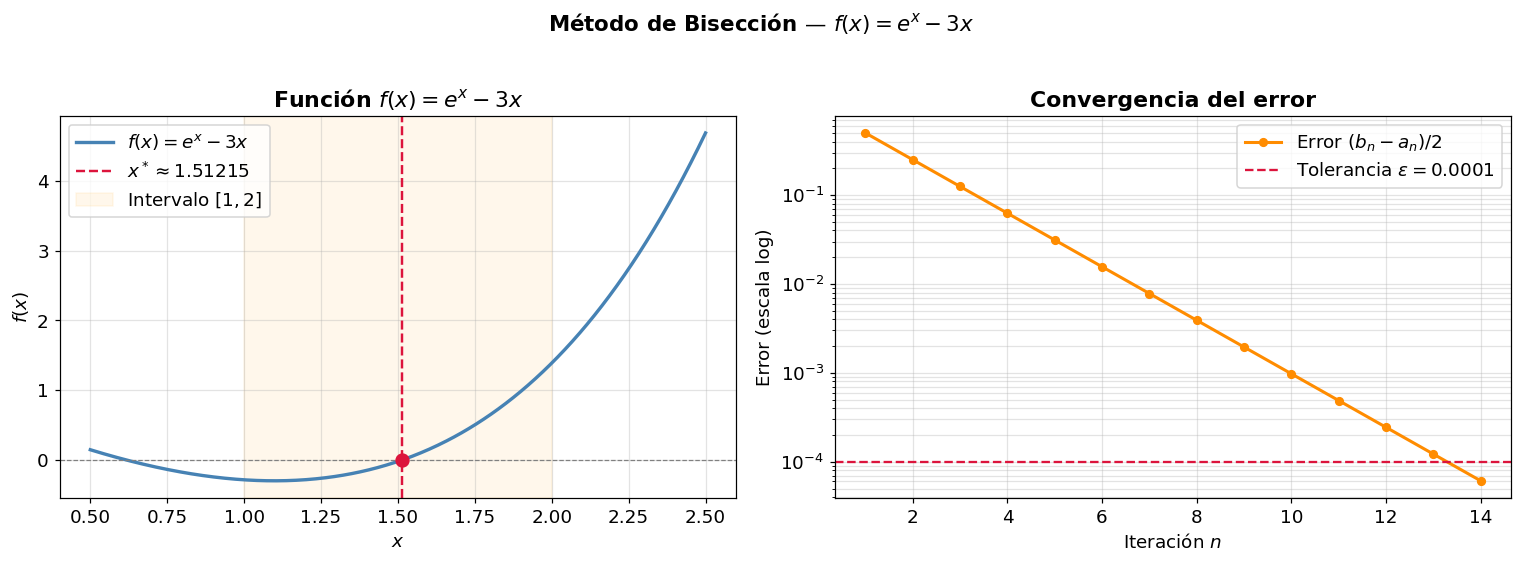

Figura guardada como 'biseccion_grafica.png'


In [5]:
x = np.linspace(0.5, 2.5, 500)
y = f(x)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Gráfica izquierda: función ────────────────────────────────────────────────
ax = axes[0]
ax.plot(x, y, color='steelblue', lw=2.2, label=r'$f(x)=e^x-3x$')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(raiz, color='crimson', lw=1.6, ls='--', label=f'$x^*\\approx{raiz:.5f}$')
ax.scatter([raiz], [f(raiz)], color='crimson', zorder=5, s=70)

# Sombreado del intervalo inicial
ax.axvspan(a0, b0, alpha=0.08, color='orange', label='Intervalo $[1,2]$')

ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('Función $f(x) = e^x - 3x$', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.35)

# ── Gráfica derecha: convergencia del error ──────────────────────────────────
ax2 = axes[1]
errores = [row['error'] for row in tabla]
iteraciones = [row['n'] for row in tabla]

ax2.semilogy(iteraciones, errores, 'o-', color='darkorange', lw=2, ms=5, label='Error $(b_n-a_n)/2$')
ax2.axhline(tol, color='crimson', ls='--', lw=1.5, label=f'Tolerancia $\\varepsilon={tol}$')
ax2.set_xlabel('Iteración $n$')
ax2.set_ylabel('Error (escala log)')
ax2.set_title('Convergencia del error', fontweight='bold')
ax2.legend()
ax2.grid(True, which='both', alpha=0.35)
ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.suptitle('Método de Bisección — $f(x)=e^x-3x$', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('biseccion_grafica.png', bbox_inches='tight', dpi=130)
plt.show()
print("Figura guardada como 'biseccion_grafica.png'")

### 4.2 Evolución de $c_n$ hacia la raíz

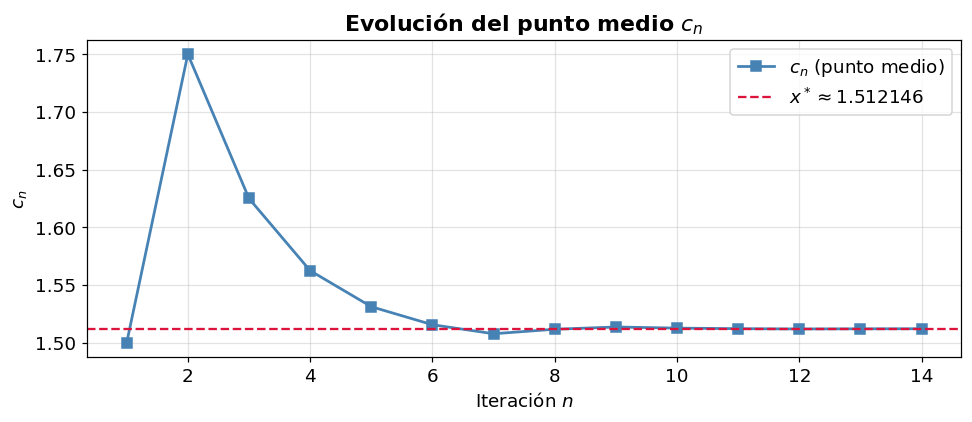

In [6]:
cn_vals = [row['c_n'] for row in tabla]
n_vals  = [row['n']   for row in tabla]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(n_vals, cn_vals, 's-', color='steelblue', lw=1.8, ms=6, label='$c_n$ (punto medio)')
ax.axhline(raiz, color='crimson', ls='--', lw=1.5, label=f'$x^*\\approx{raiz:.6f}$')
ax.set_xlabel('Iteración $n$')
ax.set_ylabel('$c_n$')
ax.set_title('Evolución del punto medio $c_n$', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.35)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

## 5. Resumen de resultados

In [11]:
raiz_exacta = 1.5121345516554428   # valor de referencia de alta precisión
error_abs   = abs(raiz - raiz_exacta)

print("╔══════════════════════════════════════════════════════╗")
print("║           RESUMEN DE RESULTADOS                      ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Función         : f(x) = eˣ - 3x                    ║")
print(f"║  Intervalo       : [1, 2]                            ║")
print(f"║  Tolerancia      : ε = {tol}                        ║")
print(f"║  Iteraciones     : {len(tabla)}                                ║")
print(f"║  Raíz aproximada : x* ≈ {raiz:.7f}                    ║")
print(f"║  Raíz exacta     : x* ≈ {raiz_exacta:.7f}                    ║")
print(f"║  Error absoluto  : |x*_aprox - x*_exacta| ≈ {error_abs:.2e} ║")
print(f"║  f(x*)           : {f(raiz):.2e} ≈ 0                      ║")
print("╚══════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════╗
║           RESUMEN DE RESULTADOS                      ║
╠══════════════════════════════════════════════════════╣
║  Función         : f(x) = eˣ - 3x                    ║
║  Intervalo       : [1, 2]                            ║
║  Tolerancia      : ε = 0.0001                        ║
║  Iteraciones     : 14                                ║
║  Raíz aproximada : x* ≈ 1.5121460                    ║
║  Raíz exacta     : x* ≈ 1.5121346                    ║
║  Error absoluto  : |x*_aprox - x*_exacta| ≈ 1.14e-05 ║
║  f(x*)           : 1.76e-05 ≈ 0                      ║
╚══════════════════════════════════════════════════════╝


## Ejercicio 2: Punto fijo del coseno — Constante de Dottie

La ecuación $\cos(x) = x$ tiene una única solución en $[0, \pi/2]$, conocida como el **punto fijo del coseno** o **constante de Dottie** ($x^* \approx 0.7391$).

**Objetivo:** Aplicar bisección en $[0, 1]$ hasta alcanzar $\varepsilon = 10^{-5}$ (error en longitud del intervalo).

## 1. Reformulación y verificación del intervalo

Reformulamos $\cos(x) = x$ como $g(x) = \cos(x) - x = 0$ y verificamos el **Teorema de Bolzano** en $[0, 1]$.

In [12]:
def g(x):
    """g(x) = cos(x) - x  (raíz ↔ punto fijo del coseno)"""
    return np.cos(x) - x

a0, b0 = 0.0, 1.0
tol = 1e-5

ga, gb = g(a0), g(b0)

print("=" * 58)
print("  Verificación del Teorema de Bolzano")
print("=" * 58)
print(f"  g({a0}) = cos({a0}) − {a0} = {ga:.6f}  {'> 0 ✓' if ga > 0 else '< 0 ✗'}")
print(f"  g({b0}) = cos({b0}) − {b0} = {gb:.6f}  {'< 0 ✓' if gb < 0 else '> 0 ✗'}")
print(f"  g(a)·g(b) = {ga*gb:.6f}  {'< 0 → existe raíz en [0,1] ✓' if ga*gb < 0 else '≥ 0 ✗'}")
print("=" * 58)

n_min = int(np.ceil(np.log2((b0 - a0) / tol)))
print(f"\n  Iteraciones estimadas: n > log₂(1/{tol}) = {np.log2(1/tol):.4f}")
print(f"  → Se requieren al menos n = {n_min} iteraciones")

  Verificación del Teorema de Bolzano
  g(0.0) = cos(0.0) − 0.0 = 1.000000  > 0 ✓
  g(1.0) = cos(1.0) − 1.0 = -0.459698  < 0 ✓
  g(a)·g(b) = -0.459698  < 0 → existe raíz en [0,1] ✓

  Iteraciones estimadas: n > log₂(1/1e-05) = 16.6096
  → Se requieren al menos n = 17 iteraciones


## 2. Algoritmo de Bisección

In [14]:
def biseccion(f, a, b, tol=1e-5, max_iter=200):
    """
    Método de bisección para encontrar raíces de f en [a, b].

    Parámetros
    ----------
    f        : función continua con f(a)·f(b) < 0
    a, b     : extremos del intervalo
    tol      : tolerancia sobre la longitud del intervalo (b−a)/2
    max_iter : máximo de iteraciones permitidas

    Retorna
    -------
    tabla : lista de dicts con el detalle de cada iteración
    raiz  : aproximación final de la raíz
    """
    if f(a) * f(b) >= 0:
        raise ValueError("f(a) y f(b) deben tener signos opuestos.")

    tabla = []
    for n in range(1, max_iter + 1):
        c  = (a + b) / 2.0
        fc = f(c)
        error = (b - a) / 2.0

        tabla.append({
            'n'     : n,
            'a_n'   : a,
            'b_n'   : b,
            'c_n'   : c,
            'g(c_n)': fc,
            'error' : error
        })

        if error < tol or fc == 0:
            break

        if f(a) * fc < 0:
            b = c
        else:
            a = c

    return tabla, c


tabla, raiz = biseccion(g, a0, b0, tol=tol)
print(f"Algoritmo ejecutado — {len(tabla)} iteraciones totales.")

Algoritmo ejecutado — 17 iteraciones totales.


## 3. Tabla de iteraciones completa

In [15]:
df = pd.DataFrame(tabla)
df['signo'] = df['g(c_n)'].apply(lambda v: '< 0' if v < 0 else '> 0')

display_df = df[['n', 'a_n', 'b_n', 'c_n', 'g(c_n)', 'signo', 'error']].copy()
display_df.columns = ['n', 'aₙ', 'bₙ', 'cₙ', 'g(cₙ)', 'signo', 'error = (b−a)/2']

pd.set_option('display.float_format', '{:.8f}'.format)
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 110)

print("=" * 90)
print("         TABLA DE ITERACIONES — Método de Bisección")
print(f"         g(x) = cos(x) − x,  [a,b] = [0, 1],  ε = {tol}")
print("=" * 90)
print(display_df.to_string(index=False))
print("=" * 90)
print(f"\n  Raíz aproximada  : x* ≈ {raiz:.8f}")
print(f"  Total iteraciones: {len(tabla)}")

         TABLA DE ITERACIONES — Método de Bisección
         g(x) = cos(x) − x,  [a,b] = [0, 1],  ε = 1e-05
 n         aₙ         bₙ         cₙ       g(cₙ) signo  error = (b−a)/2
 1 0.00000000 1.00000000 0.50000000  0.37758256   > 0       0.50000000
 2 0.50000000 1.00000000 0.75000000 -0.01831113   < 0       0.25000000
 3 0.50000000 0.75000000 0.62500000  0.18596312   > 0       0.12500000
 4 0.62500000 0.75000000 0.68750000  0.08533495   > 0       0.06250000
 5 0.68750000 0.75000000 0.71875000  0.03387937   > 0       0.03125000
 6 0.71875000 0.75000000 0.73437500  0.00787473   > 0       0.01562500
 7 0.73437500 0.75000000 0.74218750 -0.00519571   < 0       0.00781250
 8 0.73437500 0.74218750 0.73828125  0.00134515   > 0       0.00390625
 9 0.73828125 0.74218750 0.74023438 -0.00192387   < 0       0.00195312
10 0.73828125 0.74023438 0.73925781 -0.00028901   < 0       0.00097656
11 0.73828125 0.73925781 0.73876953  0.00052816   > 0       0.00048828
12 0.73876953 0.73925781 0.73901367  0.0

## 4. Verificación del resultado

Sustituimos $x^*$ en la ecuación original $\cos(x) = x$ para comprobar la solución.

In [16]:
cos_raiz = np.cos(raiz)
diferencia = abs(cos_raiz - raiz)

print("=" * 50)
print("  Verificación: cos(x*) ≈ x*")
print("=" * 50)
print(f"  x*           = {raiz:.8f}")
print(f"  cos(x*)      = {cos_raiz:.8f}")
print(f"  |cos(x*)−x*| = {diferencia:.2e}  {'✓ dentro de tolerancia' if diferencia < tol else '✗ fuera de tolerancia'}")
print(f"  g(x*)        = {g(raiz):.2e}  ≈ 0 ✓")
print("=" * 50)

  Verificación: cos(x*) ≈ x*
  x*           = 0.73908234
  cos(x*)      = 0.73908702
  |cos(x*)−x*| = 4.68e-06  ✓ dentro de tolerancia
  g(x*)        = 4.68e-06  ≈ 0 ✓


## 5. Visualización
### 5.1 Gráfica de $y = \cos(x)$ y $y = x$ — intersección en $x^*$

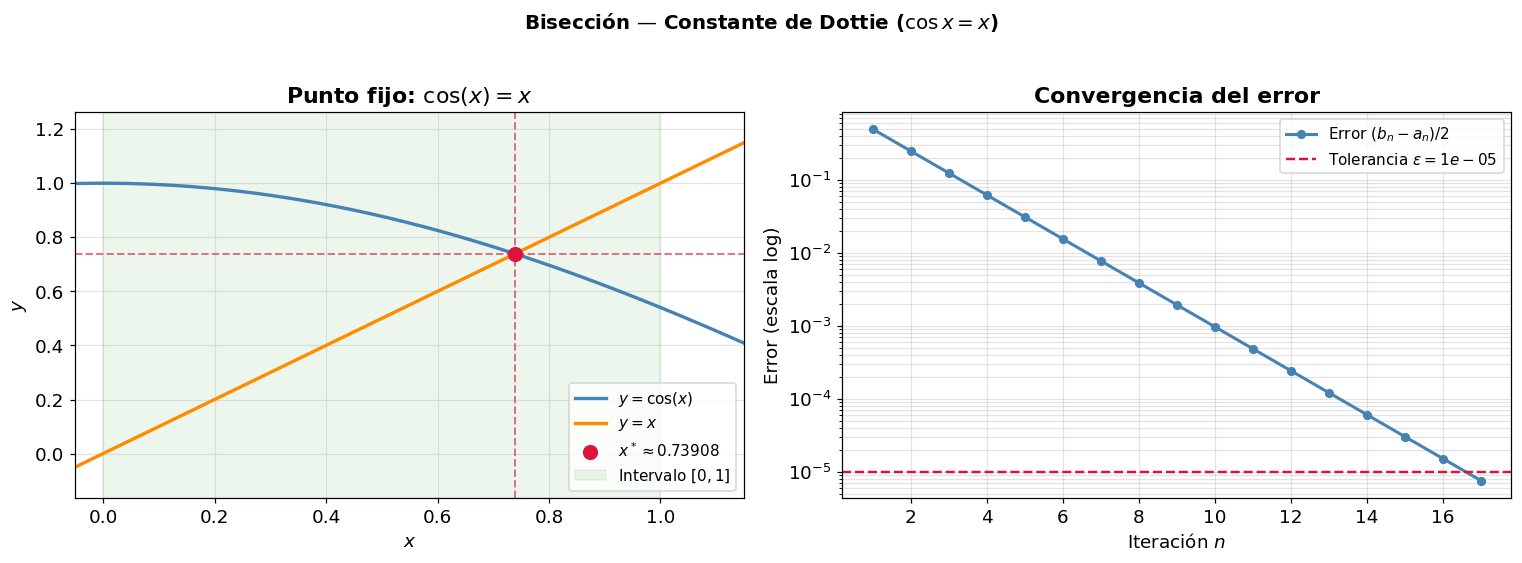

Figura guardada como 'biseccion_dottie.png'


In [17]:
x_plot = np.linspace(-0.1, 1.2, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Izquierda: cos(x) vs x ────────────────────────────────────────────────────
ax = axes[0]
ax.plot(x_plot, np.cos(x_plot), color='steelblue',  lw=2.2, label=r'$y = \cos(x)$')
ax.plot(x_plot, x_plot,         color='darkorange', lw=2.2, label=r'$y = x$')
ax.scatter([raiz], [raiz], color='crimson', zorder=6, s=80,
           label=f'$x^* \\approx {raiz:.5f}$')
ax.axvline(raiz, color='crimson', lw=1.3, ls='--', alpha=0.6)
ax.axhline(raiz, color='crimson', lw=1.3, ls='--', alpha=0.6)
ax.axvspan(a0, b0, alpha=0.07, color='green', label='Intervalo $[0,1]$')
ax.set_xlim(-0.05, 1.15)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title(r'Punto fijo: $\cos(x) = x$', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.35)

# ── Derecha: convergencia del error ──────────────────────────────────────────
ax2 = axes[1]
ns      = [r['n']     for r in tabla]
errores = [r['error'] for r in tabla]
ax2.semilogy(ns, errores, 'o-', color='steelblue', lw=2, ms=5, label='Error $(b_n-a_n)/2$')
ax2.axhline(tol, color='crimson', ls='--', lw=1.6, label=f'Tolerancia $\\varepsilon={tol}$')
ax2.set_xlabel('Iteración $n$')
ax2.set_ylabel('Error (escala log)')
ax2.set_title('Convergencia del error', fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, which='both', alpha=0.35)
ax2.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.suptitle(r'Bisección — Constante de Dottie ($\cos x = x$)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('biseccion_dottie.png', bbox_inches='tight', dpi=130)
plt.show()
print("Figura guardada como 'biseccion_dottie.png'")

### 5.2 Evolución de $c_n$ y de $g(c_n)$ por iteración

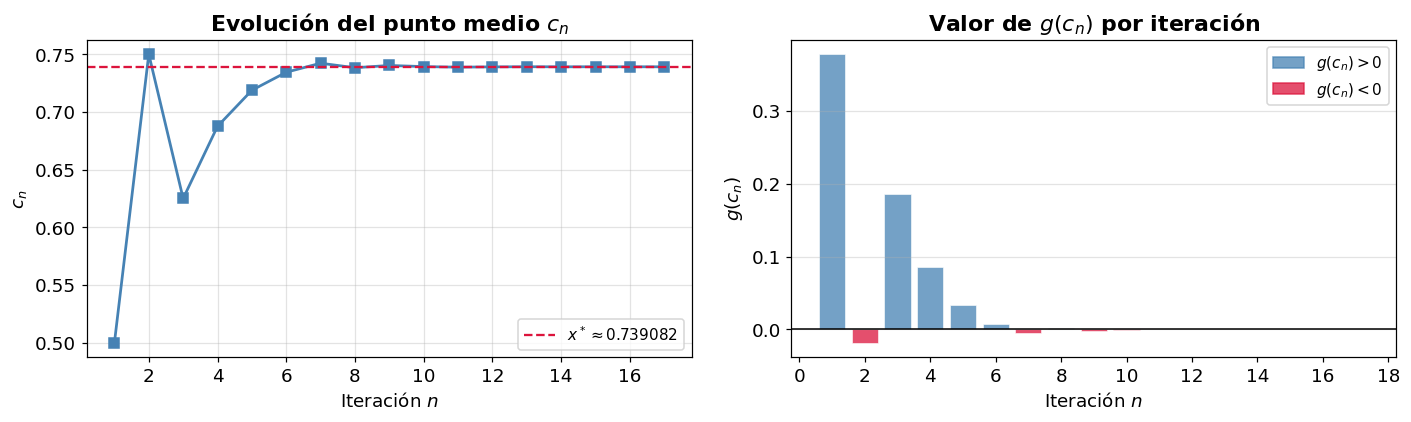

In [18]:
cn_vals  = [r['c_n']   for r in tabla]
gcn_vals = [r['g(c_n)'] for r in tabla]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Evolución de c_n
axes[0].plot(ns, cn_vals, 's-', color='steelblue', lw=1.8, ms=6)
axes[0].axhline(raiz, color='crimson', ls='--', lw=1.5, label=f'$x^* \\approx {raiz:.6f}$')
axes[0].set_xlabel('Iteración $n$')
axes[0].set_ylabel('$c_n$')
axes[0].set_title('Evolución del punto medio $c_n$', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.35)
axes[0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Evolución de g(c_n)
colors = ['crimson' if v < 0 else 'steelblue' for v in gcn_vals]
axes[1].bar(ns, gcn_vals, color=colors, alpha=0.75, edgecolor='white', linewidth=0.5)
axes[1].axhline(0, color='black', lw=1)
axes[1].set_xlabel('Iteración $n$')
axes[1].set_ylabel('$g(c_n)$')
axes[1].set_title('Valor de $g(c_n)$ por iteración', fontweight='bold')
axes[1].grid(True, axis='y', alpha=0.35)
axes[1].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Leyenda manual de colores
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color='steelblue', alpha=0.75, label='$g(c_n) > 0$'),
    Patch(color='crimson',   alpha=0.75, label='$g(c_n) < 0$')
], fontsize=10)

plt.tight_layout()
plt.show()

## 6. Resumen final

In [21]:
# Valor de referencia de alta precisión (constante de Dottie)
raiz_exacta = 0.7390851332151607
error_abs   = abs(raiz - raiz_exacta)

print("╔══════════════════════════════════════════════════════════╗")
print("║              RESUMEN DE RESULTADOS                       ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Ecuación          : cos(x) = x                          ║")
print(f"║  Función aux.      : g(x) = cos(x) − x                   ║")
print(f"║  Intervalo         : [0, 1]                              ║")
print(f"║  Tolerancia        : ε = {tol}                           ║")
print(f"║  Iteraciones       : {len(tabla)}                                  ║")
print(f"║  Raíz aproximada   : x* ≈ {raiz:.8f}                     ║")
print(f"║  Constante Dottie  : x* ≈ {raiz_exacta:.8f}                     ║")
print(f"║  Error absoluto    : {error_abs:.2e}                            ║")
print(f"║  Verificación      : cos(x*) = {np.cos(raiz):.8f} ≈ x* ✓         ║")
print("╚══════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════╗
║              RESUMEN DE RESULTADOS                       ║
╠══════════════════════════════════════════════════════════╣
║  Ecuación          : cos(x) = x                          ║
║  Función aux.      : g(x) = cos(x) − x                   ║
║  Intervalo         : [0, 1]                              ║
║  Tolerancia        : ε = 1e-05                           ║
║  Iteraciones       : 17                                  ║
║  Raíz aproximada   : x* ≈ 0.73908234                     ║
║  Constante Dottie  : x* ≈ 0.73908513                     ║
║  Error absoluto    : 2.80e-06                            ║
║  Verificación      : cos(x*) = 0.73908702 ≈ x* ✓         ║
╚══════════════════════════════════════════════════════════╝
